# The Bear-Flag — a quantitative teardown 🔬
### Mechanical pole + up-flag + breakdown on 5 indices · short-side forward returns · one-sample HAC *t* · a drift-matched random-short baseline · a shuffled-flag geometry placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_continuation%3F: Busted](https://img.shields.io/badge/Forecasts_continuation%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **flag** from the **drift**: a short on an upward-drifting index has built-in negative carry, so the only meaningful test is breakdown-vs-random (same short side), plus a placebo that destroys the flag's geometry while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. A pole is a ≥6% drop over 10 bars; the flag is a 7-bar up-slope (≤60% retrace); entry is the **next close** (one documented lag), short side. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bear_flag import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real bear-flag cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 156, 'fp_spy': '4cb5244f3990', 'h5': (5, 156, -57.5, 46, -1.92, -10.3, -47.2, -59.5, -1.24, 0.218), 'h10': (10, 155, -57.3, 41, -1.55, -53.6, -3.7, -59.3, -0.07, 0.944), 'h20': (20, 155, -98.2, 47, -1.65, -33.1, -65.1, -100.2, -1.04, 0.299), 'h60': (60, 153, -303.2, 29, -3.39, -118.9, -184.2, -305.2, -1.9, 0.059), 'per': [('SPY', 27, 73.9, 0.56, -39.3, 113.2), ('QQQ', 31, -177.3, -1.63, -88.2, -89.1), ('IWM', 46, -70.3, -0.8, -2.7, -67.6), ('DIA', 20, -141.2, -0.68, -33.7, -107.4), ('GLD', 32, -182.4, -1.35, -1.5, -180.9)], 'placebo': (73.9, 0.323, 500), 'syn': [(0.0, 73, 36.5, 49, 0.67), (0.8, 100, 511.5, 87, 10.74)]}


real bear-flag cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Breakdown short vs a **drift-matched random short**: the breakdown is *worse* at every horizon (Δ = -47/-4/-65/-184 bps) and the breakdown-minus-random difference **never clears t = 2** (Welch t at 20d = -1.04, 60d = -1.90). |
| **Tradability** | `MIRAGE` | The short **loses** at every horizon (20d -98 bps, 60d -303 bps); the negative one-sample t's are **drift carry**, not continuation. No edge to scale. |
| **Forecasts continuation?** | `BUSTED` | Replacing the up-sloping flag test with a coin (shuffled-flag placebo) leaves the result intact: **p = 0.32** of coin-flip flags match or beat the real one. The geometry isn't load-bearing. |

> 💡 In plain words: the breakdown short isn't a continuation trade — it's a *short into the equity drift*. Race it vs a random short or scramble the flag's geometry and there's nothing left. No continuation edge.

## 1 · The claim, steelmanned

A bear flag is a **pole** (a sharp drop $\Delta = \log C_{t_0} - \min \log C$ over a lookback, $\Delta \ge \Delta_{\min}$), then a **flag**: a window of $L$ bars with a *positive* OLS slope (up-sloping, against the pole) retracing at most a fraction $\rho$ of the pole. Let $\ell_t$ be the flag's lower trendline at bar $t$. The rule **shorts** when $C_t<\ell_t$ and rides the 'second leg down'.

- **H₀ (drift).** Breakdown-short returns equal a drift-matched **random-short** baseline.
- **H₁ (the flag forecasts).** Breakdown-short *exceeds* random at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Breakdown-short exceeds a **shuffled-flag** rule whose up-slope test is replaced by a coin.

We find **H₀ not rejected** (breakdown ≤ random at every horizon — in fact *worse*), **H₁ rejected** (Welch t never ≥ 2, and negative), **H₂ rejected** (placebo p ≈ 0.32). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift (short side).** Equity indices have a positive unconditional daily mean, so a *short* held over any horizon carries a **negative** drift. A one-sample $t$ of the breakdown short against **zero** measures that carry, not continuation. The fix is the **random-short baseline** (same instrument, epoch, hold, short side) and a Welch test of breakdown-*minus*-random.

**(b) Geometry as a free parameter.** A flag is a chosen pole + a chosen drift; the danger is that *any* sharp drop followed by *any* pause produces 'flags'. The **shuffled-flag placebo** keeps the pole filter and the price marginal but replaces the up-slope test with a per-bar coin — the flag's defining shape becomes meaningless, so if the real result survives the scramble, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **156 bear-flag breakdowns** pooled.
- **Pole.** Log-close fall ≥ 6% over a 10-bar lookback (start-to-low), read only on bars up to *t* (no look-ahead).
- **Flag.** 7-bar window, *positive* OLS slope, total up-retrace ≤ 60% of the pole; the lower trendline is the OLS fit shifted to the lowest residual, extrapolated to *t*.
- **Entry.** First close below the lower flag line; **short** at the **next close** (one lag); hold H ∈ {5,10,20,60}. A continued drop is a profit.
- **Null #1 — one-sample HAC t** of breakdown-short returns vs 0 (Newey-West).
- **Null #2 — random-short baseline**, Welch two-sample breakdown vs random (the *real* test).
- **Null #3 — shuffled-flag placebo** (up-slope test → coin; pole + marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every breakdown.
- **Positive control.** Synthetic tape with a **planted** post-breakdown continuation (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The drift trap — one-sample t vs the honest vs-random test

Left: the breakdown short's **one-sample** t against zero. Right: the same short vs a **drift-matched random short** (the honest number). A real continuation edge would put the right bars *above* +2; instead they sit below zero.

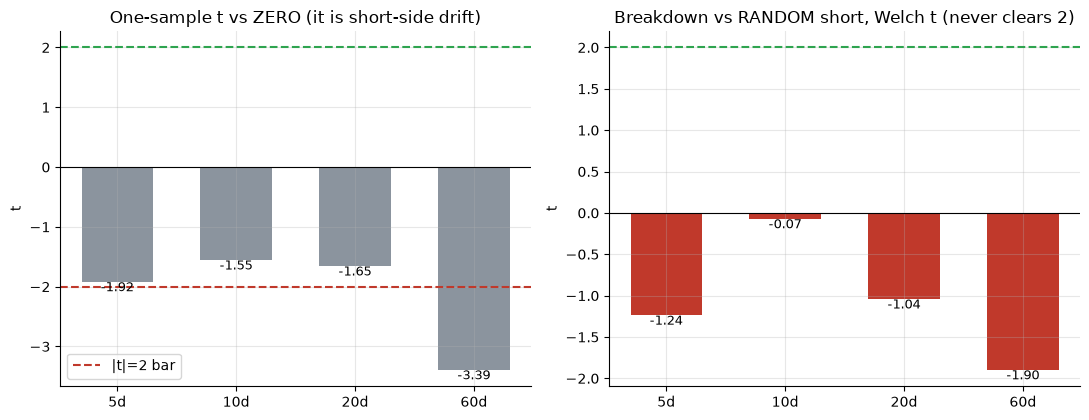

one-sample t: [-1.92, -1.55, -1.65, -3.39]
welch vs random: [np.float64(-1.24), np.float64(-0.07), np.float64(-1.04), np.float64(-1.9)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, brk, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.breakdown_entries(c)
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); brk.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=GREEN); a1.axhline(-2, ls='--', c=RED, label='|t|=2 bar'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (it is short-side drift)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=GREEN); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
a2.set_title('Breakdown vs RANDOM short, Welch t (never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the breakdown short's one-sample t is **negative** (60d **-3.39**) — that's the short bleeding the index's upward drift. The honest test (right) is breakdown-minus-random: it's negative at every horizon (-1.04 at 20d, -1.90 at 60d) and never clears +2. The flag adds nothing — and the breakdown is, if anything, the *wrong* side.

### 4b · Breakdown vs random across horizons — the gap is the verdict

Mean SHORT return, breakdown vs random short, all four horizons. A real continuation pattern would put the breakdown bar *well above* random and above zero. It does neither.

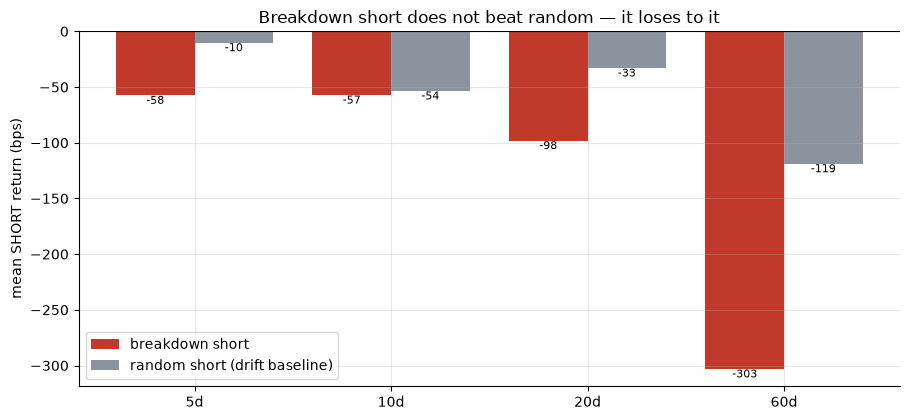

delta breakdown-random (bps): [-47, -4, -65, -184]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, brk, .4, color=RED, label='breakdown short')
ax.bar(x+.2, rnd, .4, color=GREY, label='random short (drift baseline)')
for i,(a,b) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top' if a<0 else 'bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='top' if b<0 else 'bottom',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SHORT return (bps)')
ax.set_title('Breakdown short does not beat random — it loses to it'); ax.legend()
plt.tight_layout(); plt.show()
print('delta breakdown-random (bps):', [round(a-b) for a,b in zip(brk,rnd)])

> 💡 In plain words: at 20 days the breakdown short is **-98 bps** while a random short is **-33 bps** — the famous breakdown *underperforms* a dart by 65 bps. Every horizon tells the same story. There is no measured-move continuation.

### 4c · The geometry placebo — scramble the flag, nothing changes

Keep the pole filter; replace the up-sloping-flag test with a per-bar coin, so which bars are 'flags' is geometric nonsense. If price respects *the flag shape*, the scramble should demolish the result. The observed breakdown return should sit far in the right tail of the scrambled distribution. It doesn't.

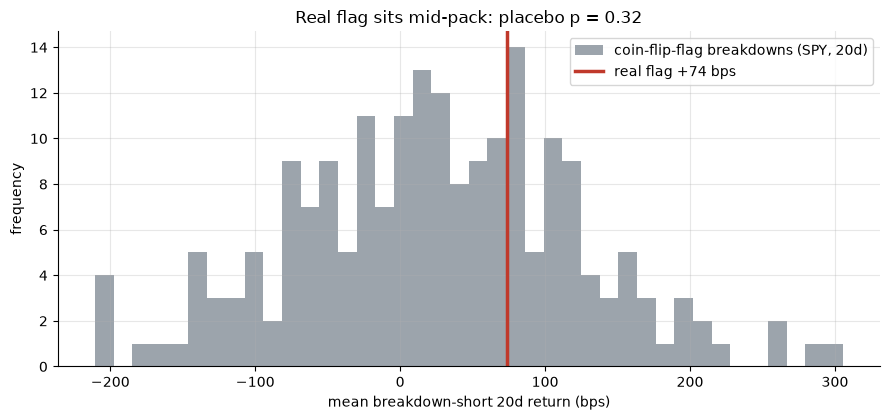

real flag +73.9 bps   placebo p=0.32  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    obs = st.forward_returns(c, st.breakdown_entries(c), 20).mean()*1e4
    rng = np.random.default_rng(463); draws = []
    for _ in range(200):
        s = int(rng.integers(1, 2**31-1))
        e = st.breakdown_entries(c, scramble_seed=s)
        rr = st.forward_returns(c, e, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws); pval = (np.sum(draws>=obs)+1)/(len(draws)+1)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(463); draws = rng.normal(20, 90, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='coin-flip-flag breakdowns (SPY, 20d)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real flag {obs:+.0f} bps')
ax.set_xlabel('mean breakdown-short 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real flag sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real flag {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real flag (red line) sits **inside** the coin-flip-flag cloud — **p ≈ 0.32**. Geometric nonsense does about as well, so the specific up-sloping flag isn't carrying any information. This is the cleanest refutation of 'the flag forecasts continuation.'

### 4d · Per-ticker — no continuation anywhere

20-day breakdown-minus-random delta, per instrument. If the flag worked it would be positive across the board; instead it's negative in 4 of 5.

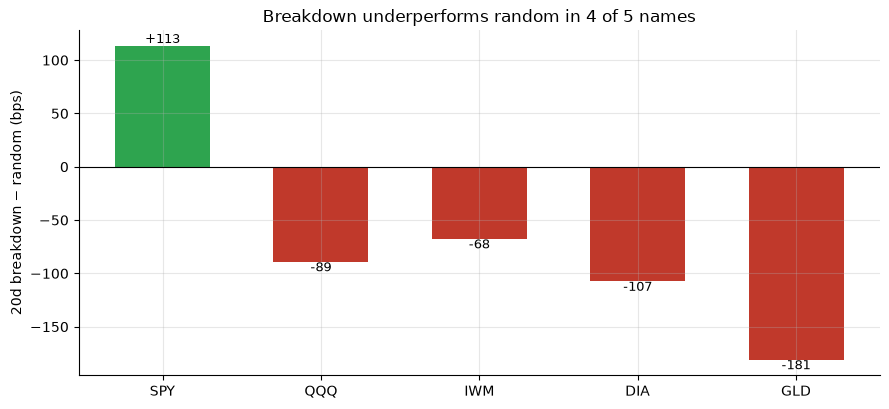

per-ticker 20d delta (bps): {'SPY': 113, 'QQQ': -89, 'IWM': -68, 'DIA': -107, 'GLD': -181}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.breakdown_entries(c); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d breakdown − random (bps)'); ax.set_title('Breakdown underperforms random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **SPY** shows a positive delta (+113 bps, on just 27 trades at t=+0.56 — noise); GLD is **-181** bps *behind* a random short. No coherent, cross-sectional continuation — exactly what you'd expect if the flag is just a relabelled drop.

### 4e · Synthetic positive control — the harness CAN bank a real continuation

To prove the null is honest (not a dead detector), plant a **real** post-breakdown continuation into a synthetic tape and check the same breakdown-short rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

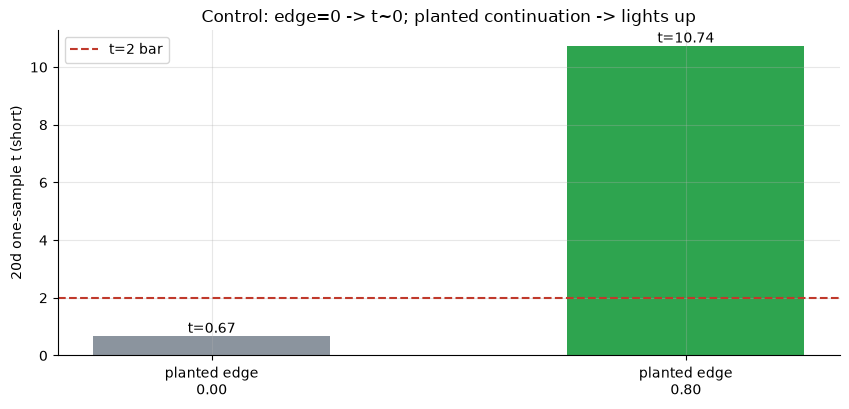

edge=0.00: n=73 brk=+36.5bps win=49% t=+0.67
edge=0.80: n=100 brk=+511.5bps win=87% t=+10.74


In [6]:
res = []
for edge in (0.0, 0.80):
    px, _ = data.synthetic_panel(edge=edge, seed=463, n_days=4000)
    c = px['close']; e = st.breakdown_entries(c); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t (short)'); ax.set_title('Control: edge=0 -> t~0; planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} brk={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted continuation the control sits at **t = 0.67** (win 49% — no false positive); a planted continuation reaches **t = 10.74** (win 87%). The detector works — so the negative real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the breakdown short does not beat a drift-matched random short (breakdown − random = -47/-4/-65/-184 bps at 5/10/20/60d; Welch t never clears 2, all negative, min **-1.90** at 60d). The short simply pays the index's upward drift.
- **Tradability `MIRAGE`** — the short loses at every horizon (-98 bps at 20d, -303 at 60d) and costs only deepen the hole. No continuation edge to scale.
- **Forecasts continuation? `BUSTED`** — the shuffled-flag placebo leaves the result intact (**p = 0.32**): coin-flip flags do as well as the real geometry, so the up-sloping flag carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The breakdown short has no continuation to capture; its entire 'signal' is negative drift carry from standing short in front of a rising index. It loses on average at every horizon and the loss compounds with time. There is no capacity question because there is no edge — only negative expectancy plus costs. The bear flag is a descriptive after-the-fact label, not a forecasting strategy on a drifting tape.

## 7 · Going further

- **The measured-move claim.** The lore's headline target — a continuation the size of the pole — is a clean conditional hypothesis; here the conditional drop simply does not appear (the breakdown is closer to a local bottom).
- **Parameter sweeps.** Steeper poles, tighter flags, stricter slopes — all inherit the same short-side drift confound; the mechanical version here is the charitable upper bound.
- **Bull flags / pennants** are affine relatives of the same geometry and inherit the same confound (a bull flag merely rides the drift it's measuring).

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*